In [1]:
# IMPOR DATA
from google.colab import auth
auth.authenticate_user()
from google.cloud import bigquery
client = bigquery.Client(project="sunlit-webbing-493405-r6")
query = """
    SELECT *
    FROM `bigquery-public-data.nhtsa_traffic_fatalities.accident_2015`
    LIMIT 1000
"""
df = client.query(query).to_dataframe()
df.head()

,state_number,state_name,consecutive_number,number_of_vehicle_forms_submitted_all,number_of_motor_vehicles_in_transport_mvit,number_of_parked_working_vehicles,number_of_forms_submitted_for_persons_not_in_motor_vehicles,number_of_persons_not_in_motor_vehicles_in_transport_mvit,number_of_persons_in_motor_vehicles_in_transport_mvit,number_of_forms_submitted_for_persons_in_motor_vehicles,...,minute_of_ems_arrival_at_hospital,related_factors_crash_level_1,related_factors_crash_level_1_name,related_factors_crash_level_2,related_factors_crash_level_2_name,related_factors_crash_level_3,related_factors_crash_level_3_name,number_of_fatalities,number_of_drunk_drivers,timestamp_of_crash
0,30,Montana,300019,5,5,0,0,0,7,7,...,45,0,None,0,None,0,None,1,0,2015-03-28 14:58:00+00:00
1,39,Ohio,390099,7,7,0,0,0,15,15,...,24,27,Backup Due to Prior Crash,0,None,0,None,1,0,2015-02-14 11:19:00+00:00
2,49,Utah,490123,16,16,0,0,0,28,28,...,99,0,None,0,None,0,None,1,0,2015-04-14 12:24:00+00:00
3,48,Texas,481184,6,5,1,0,5,5,10,...,99,0,None,0,None,0,None,1,0,2015-05-27 16:40:00+00:00
4,41,Oregon,410333,11,11,0,0,0,14,14,...,99,0,None,0,None,0,None,1,0,2015-11-17 18:17:00+00:00


In [2]:
# IMPOR PACKAGE
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from google.cloud import bigquery
from google.colab import auth

pd.set_option('display.max_columns', 50)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

In [3]:
# DATA UNDERSTANDING
print("DATA UNDERSTANDING")
print(f"\nJumlah baris    : {df.shape[0]}")
print(f"Jumlah kolom    : {df.shape[1]}")
print("\nTipe data:")
print(df.dtypes)
print("\nStatistik deskriptif:")
df[['hour_of_crash', 'month_of_crash', 'day_of_week',
    'number_of_fatalities', 'number_of_drunk_drivers']].describe()

DATA UNDERSTANDING

Jumlah baris    : 1000
Jumlah kolom    : 70

Tipe data:
state_number                                                Int64
state_name                                                 object
consecutive_number                                          Int64
number_of_vehicle_forms_submitted_all                       Int64
number_of_motor_vehicles_in_transport_mvit                  Int64
                                                     ...         
related_factors_crash_level_3                               Int64
related_factors_crash_level_3_name                         object
number_of_fatalities                                        Int64
number_of_drunk_drivers                                     Int64
timestamp_of_crash                            datetime64[us, UTC]
Length: 70, dtype: object

Statistik deskriptif:


,hour_of_crash,month_of_crash,day_of_week,number_of_fatalities,number_of_drunk_drivers
count,1000.0,1000.0,1000.0,1000.0,1000.0
mean,13.065,6.789,4.052,1.137,0.266
std,12.021784,3.695692,2.140064,0.590406,0.448827
min,0.0,1.0,1.0,1.0,0.0
25%,6.0,3.0,2.0,1.0,0.0
50%,13.0,7.0,4.0,1.0,0.0
75%,18.0,10.0,6.0,1.0,1.0
max,99.0,12.0,7.0,10.0,2.0


In [4]:
# CEK KUALITAS DATA
print("CEK KUALITAS DATA")
# Missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Jumlah Missing': missing,
    'Persentase (%)': missing_pct
}).query('`Jumlah Missing` > 0').sort_values('Persentase (%)', ascending=False)
print("\nKolom dengan missing values:")
print(missing_df if len(missing_df) > 0 else "Tidak ada missing values!")
# Duplikasi
print(f"\nJumlah duplikat : {df.duplicated().sum()}")
# Cek nilai unknown kolom utama (99 = unknown di NHTSA)
print("\nNilai unik hour_of_crash  :", sorted(df['hour_of_crash'].unique()))
print("Nilai unik month_of_crash :", sorted(df['month_of_crash'].unique()))
print("Nilai unik day_of_week    :", sorted(df['day_of_week'].unique()))

CEK KUALITAS DATA

Kolom dengan missing values:
Tidak ada missing values!

Jumlah duplikat : 0

Nilai unik hour_of_crash  : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(99)]
Nilai unik month_of_crash : [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]
Nilai unik day_of_week    : [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]


In [5]:
# PREPOCESSING
print("PREPROCESSING")
df_clean = df.copy()
df_clean = df_clean.drop_duplicates()
df_clean['hour_of_crash']  = df_clean['hour_of_crash'].replace(99, np.nan)
df_clean['month_of_crash'] = df_clean['month_of_crash'].replace(99, np.nan)
df_clean['day_of_week']    = df_clean['day_of_week'].replace(9, np.nan)
df_clean = df_clean.dropna(subset=['hour_of_crash', 'month_of_crash', 'day_of_week'])
df_clean['hour_of_crash']       = df_clean['hour_of_crash'].astype(int)
df_clean['month_of_crash']      = df_clean['month_of_crash'].astype(int)
df_clean['day_of_week']         = df_clean['day_of_week'].astype(int)
df_clean['number_of_fatalities']= df_clean['number_of_fatalities'].astype(int)
def kategorikan_waktu(h):
    if 0 <= h <= 5:    return 'Dini hari (00-05)'
    elif 6 <= h <= 11: return 'Pagi (06-11)'
    elif 12 <= h <= 17: return 'Siang (12-17)'
    else:              return 'Malam (18-23)'
df_clean['waktu_kategori'] = df_clean['hour_of_crash'].apply(kategorikan_waktu)
def kategori_hari(d):
    return 'Akhir Pekan' if d in [1, 7] else 'Hari Kerja'
df_clean['tipe_hari'] = df_clean['day_of_week'].apply(kategori_hari)
nama_hari_map = {1:'Minggu', 2:'Senin', 3:'Selasa', 4:'Rabu',
                 5:'Kamis',  6:'Jumat', 7:'Sabtu'}
df_clean['nama_hari'] = df_clean['day_of_week'].map(nama_hari_map)
print(f"Shape sebelum cleaning : {df.shape}")
print(f"Shape sesudah cleaning : {df_clean.shape}")
print(f"Baris dihapus          : {df.shape[0] - df_clean.shape[0]}")
print("\nPreview kolom baru:")
df_clean[['hour_of_crash', 'waktu_kategori',
          'day_of_week', 'tipe_hari', 'nama_hari']].head(10)

PREPROCESSING
Shape sebelum cleaning : (1000, 70)
Shape sesudah cleaning : (987, 73)
Baris dihapus          : 13

Preview kolom baru:


,hour_of_crash,waktu_kategori,day_of_week,tipe_hari,nama_hari
0,14,Siang (12-17),7,Akhir Pekan,Sabtu
1,11,Pagi (06-11),7,Akhir Pekan,Sabtu
2,12,Siang (12-17),3,Hari Kerja,Selasa
3,16,Siang (12-17),4,Hari Kerja,Rabu
4,18,Malam (18-23),3,Hari Kerja,Selasa
5,11,Pagi (06-11),7,Akhir Pekan,Sabtu
6,14,Siang (12-17),7,Akhir Pekan,Sabtu
7,7,Pagi (06-11),1,Akhir Pekan,Minggu
8,14,Siang (12-17),7,Akhir Pekan,Sabtu
9,21,Malam (18-23),2,Hari Kerja,Senin


In [6]:
print("EXPLORATORY DATA ANALYSIS")
nama_bulan = ['Jan','Feb','Mar','Apr','Mei','Jun',
              'Jul','Agu','Sep','Okt','Nov','Des']
urutan_hari = ['Senin','Selasa','Rabu','Kamis','Jumat','Sabtu','Minggu']
per_jam    = df_clean['hour_of_crash'].value_counts().sort_index()
per_bulan  = df_clean['month_of_crash'].value_counts().sort_index()
per_hari   = df_clean['nama_hari'].value_counts().reindex(urutan_hari)
per_tipe   = df_clean['tipe_hari'].value_counts()
per_waktu  = df_clean['waktu_kategori'].value_counts()
per_state  = df_clean.groupby('state_name')['number_of_fatalities'].sum().sort_values(ascending=False)
print("\nDistribusi kategori waktu:")
print(per_waktu)
print("\nDistribusi hari kerja vs akhir pekan:")
print(per_tipe)
print("\nTop 5 state paling fatal:")
print(per_state.head())

EXPLORATORY DATA ANALYSIS

Distribusi kategori waktu:
waktu_kategori
Malam (18-23)        269
Siang (12-17)        264
Dini hari (00-05)    233
Pagi (06-11)         221
Name: count, dtype: int64

Distribusi hari kerja vs akhir pekan:
tipe_hari
Hari Kerja     634
Akhir Pekan    353
Name: count, dtype: int64

Top 5 state paling fatal:
state_name
Texas        124
Georgia       72
Florida       71
Tennessee     51
New York      50
Name: number_of_fatalities, dtype: int64


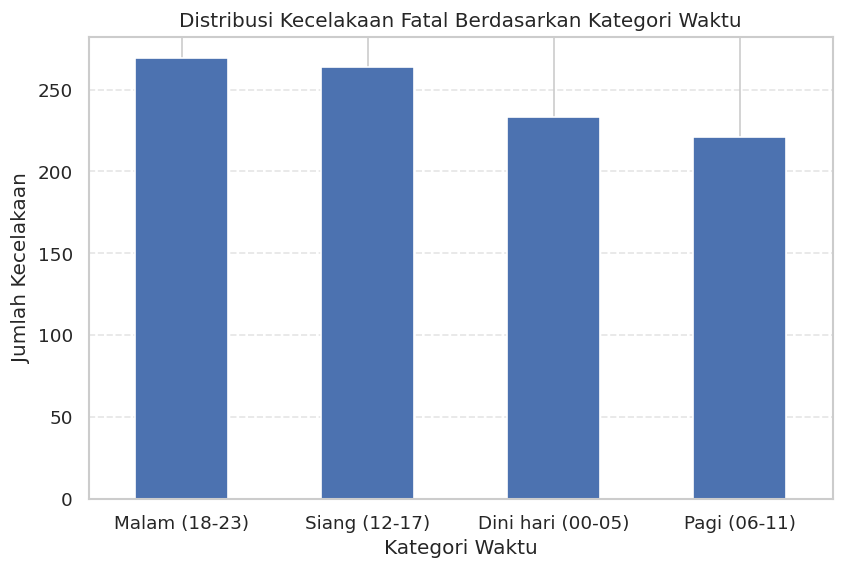

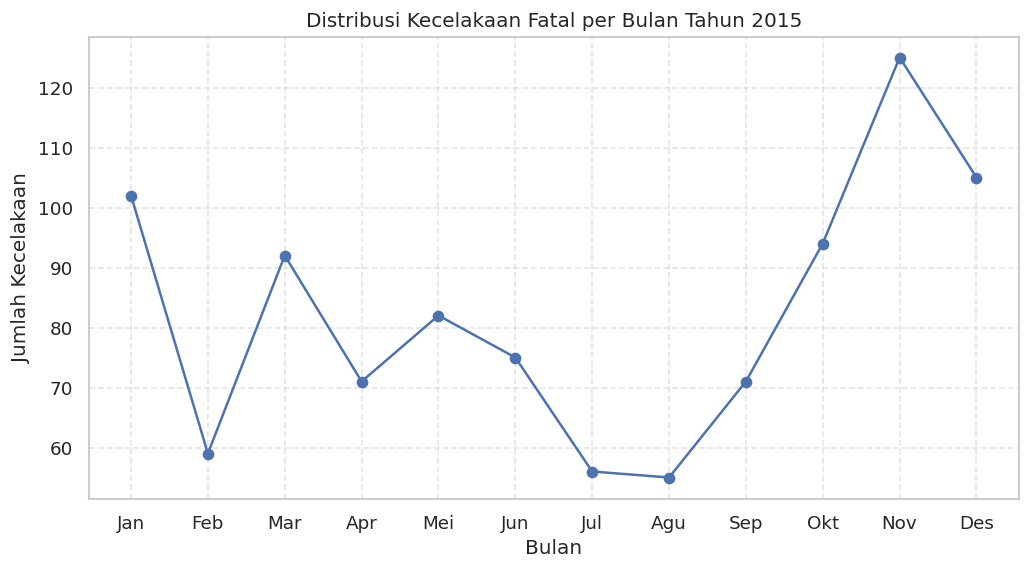

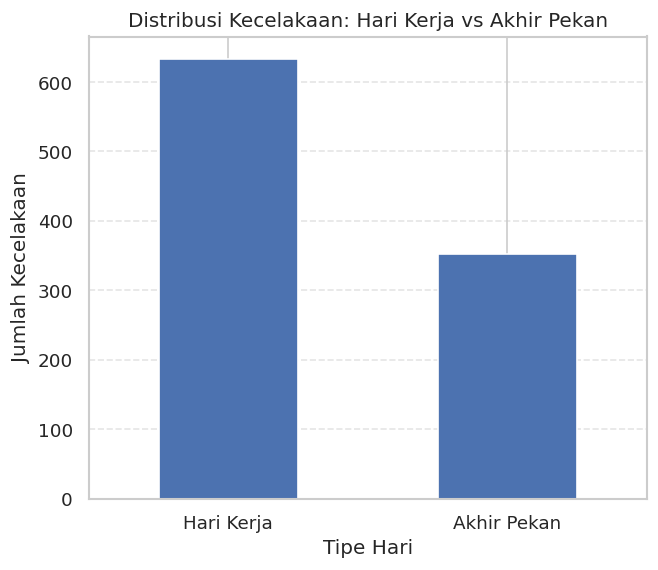

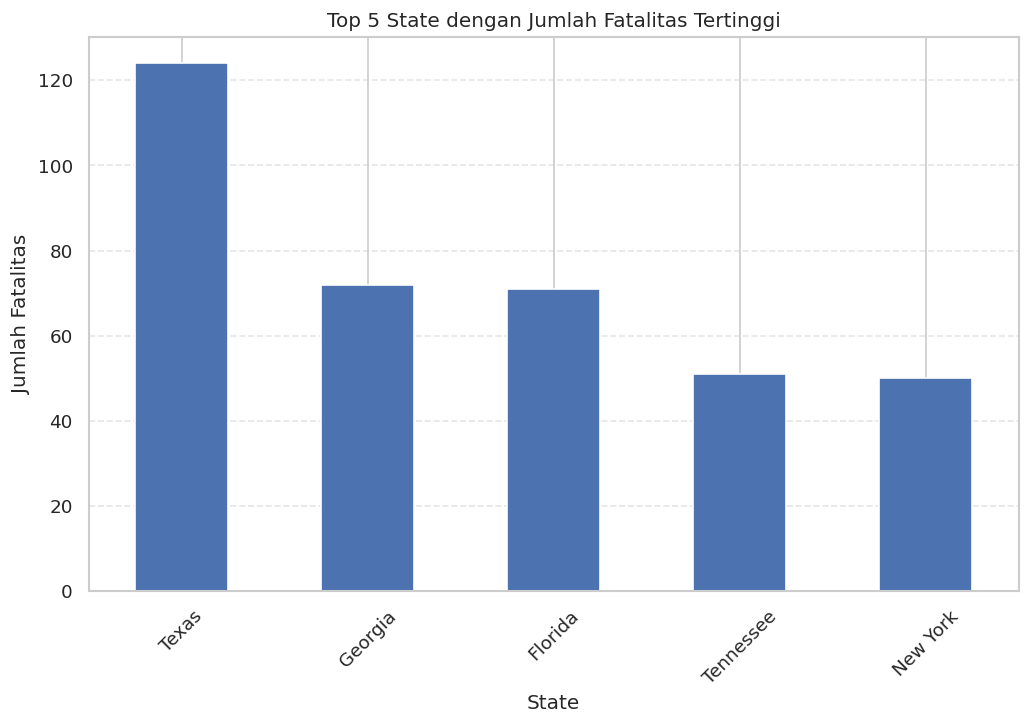

In [7]:
# =========================
# VISUALISASI EDA
# =========================

import matplotlib.pyplot as plt
import plotly.express as px

# -------------------------
# 1. Bar Chart Kategori Waktu
# -------------------------
plt.figure(figsize=(8,5))
per_waktu.plot(kind='bar')

plt.title('Distribusi Kecelakaan Fatal Berdasarkan Kategori Waktu')
plt.xlabel('Kategori Waktu')
plt.ylabel('Jumlah Kecelakaan')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()


# -------------------------
# 2. Line Chart Per Bulan
# -------------------------
plt.figure(figsize=(10,5))

plt.plot(nama_bulan, per_bulan.values, marker='o')

plt.title('Distribusi Kecelakaan Fatal per Bulan Tahun 2015')
plt.xlabel('Bulan')
plt.ylabel('Jumlah Kecelakaan')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()


# -------------------------
# 3. Bar Chart Hari Kerja vs Akhir Pekan
# -------------------------
plt.figure(figsize=(6,5))

per_tipe.plot(kind='bar')

plt.title('Distribusi Kecelakaan: Hari Kerja vs Akhir Pekan')
plt.xlabel('Tipe Hari')
plt.ylabel('Jumlah Kecelakaan')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()


# -------------------------
# 4. Bar Chart Top 5 State Paling Fatal
# -------------------------
top5_state = per_state.head(5)

plt.figure(figsize=(10,6))

top5_state.plot(kind='bar')

plt.title('Top 5 State dengan Jumlah Fatalitas Tertinggi')
plt.xlabel('State')
plt.ylabel('Jumlah Fatalitas')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()


# -------------------------
# 5. Peta Geografis Fatalitas per State
# -------------------------
df_map = per_state.reset_index()
df_map.columns = ['state_name', 'fatalities']

fig = px.choropleth(
    df_map,
    locations='state_name',
    locationmode='USA-states',
    color='fatalities',
    scope='usa',
    hover_name='state_name',
    color_continuous_scale='Reds',
    title='Peta Persebaran Fatalitas Kecelakaan di Amerika Serikat Tahun 2015'
)

fig.show()

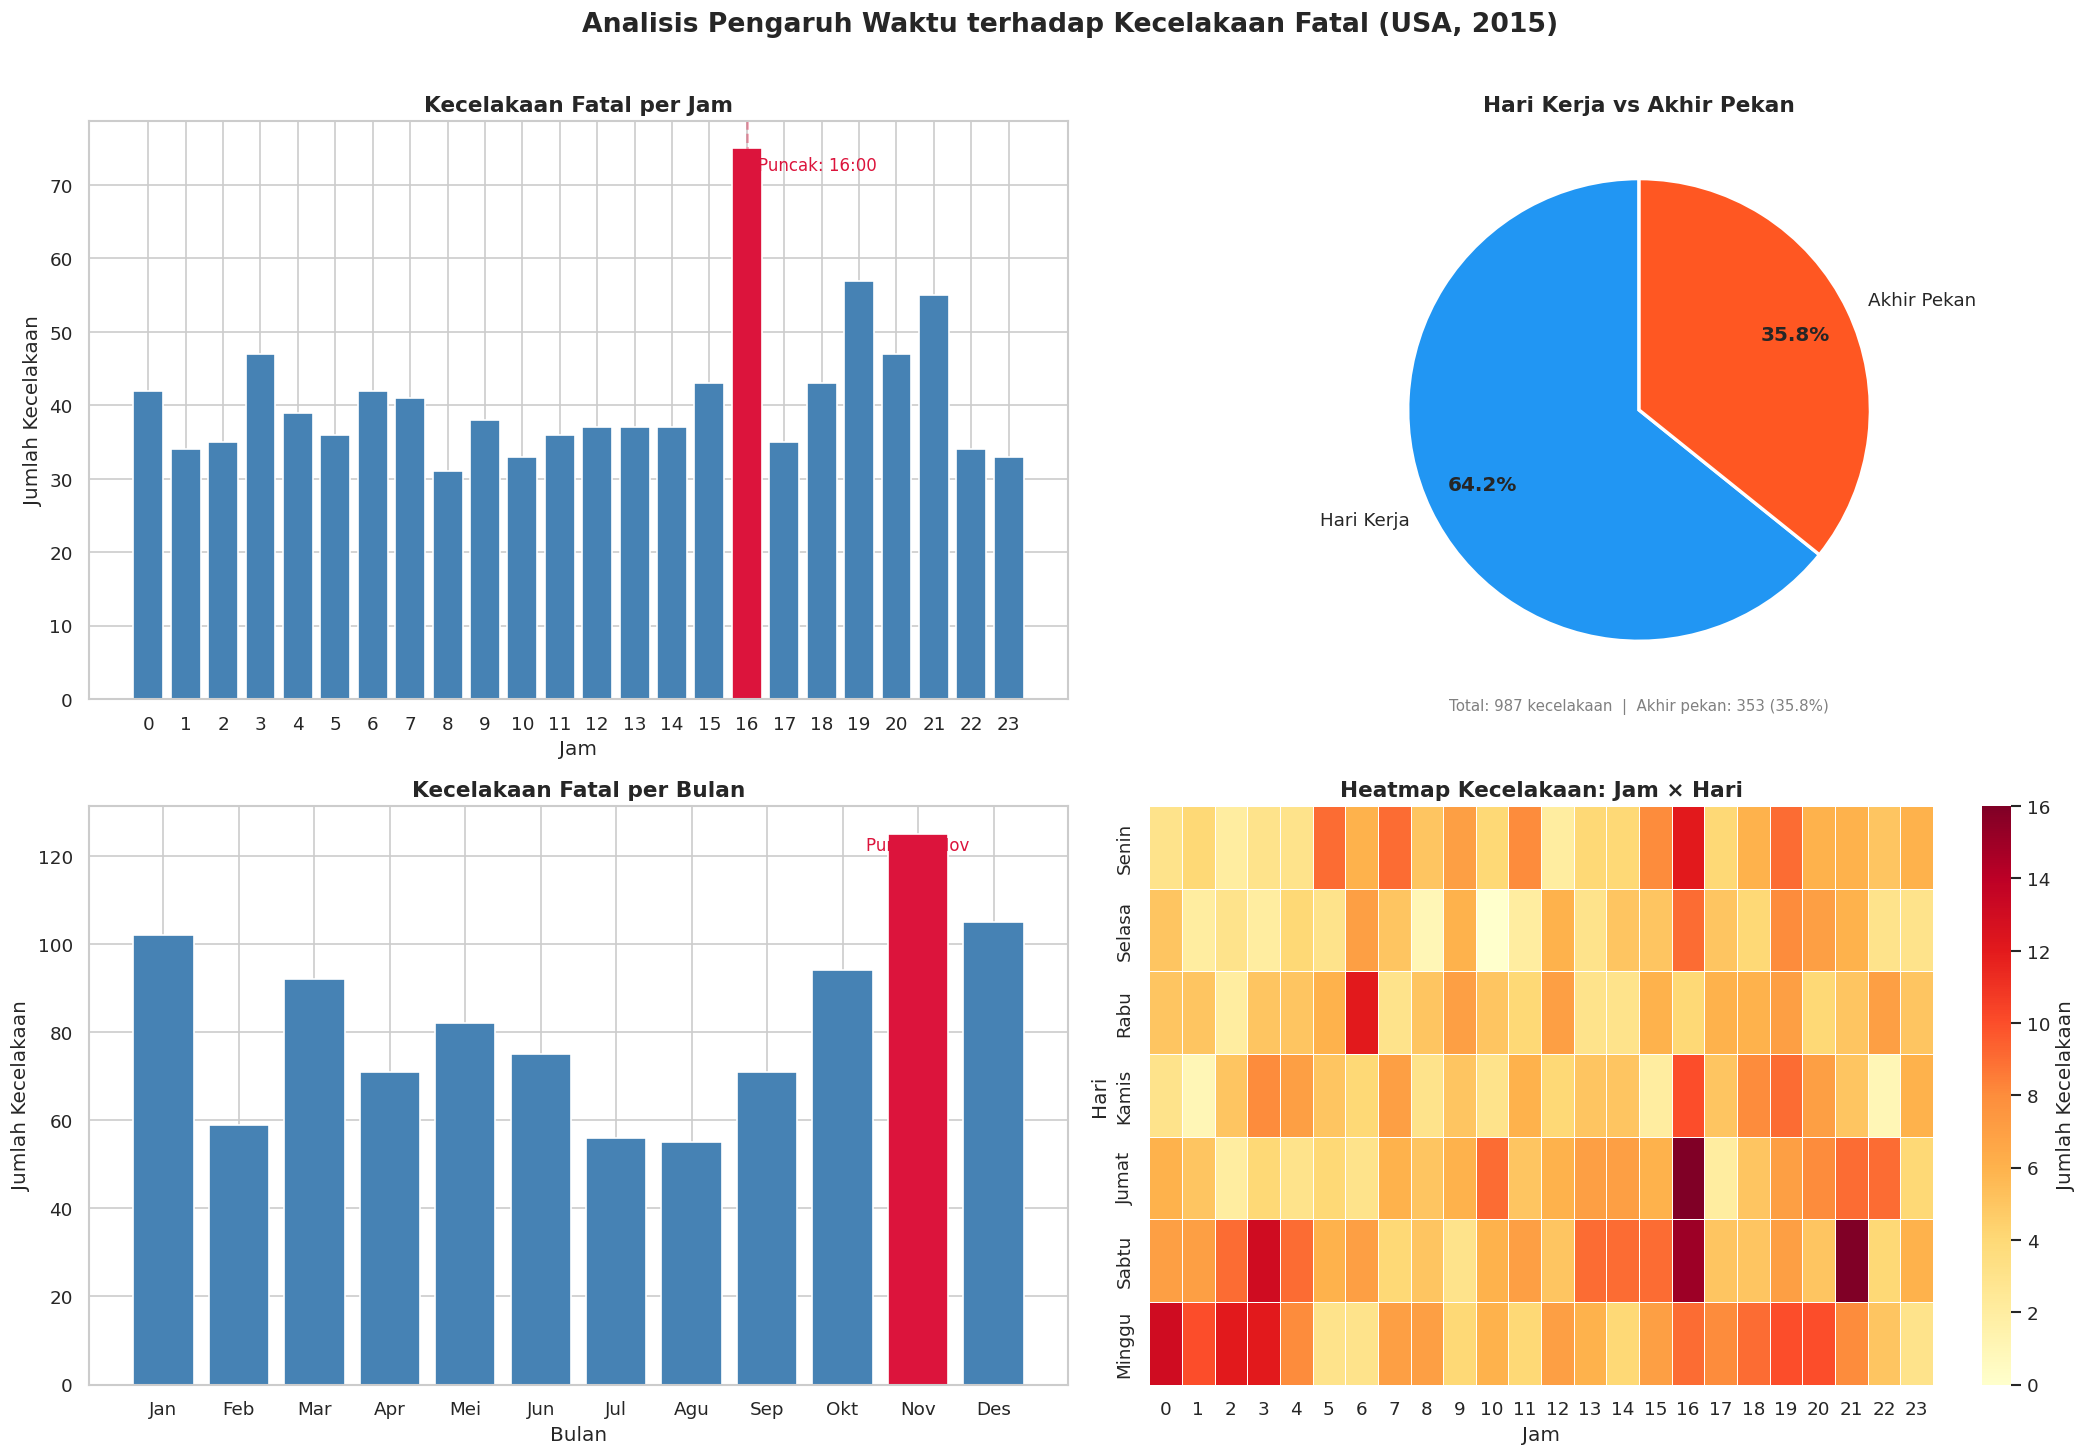

Chart 1-4 tersimpan!


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Analisis Pengaruh Waktu terhadap Kecelakaan Fatal (USA, 2015)',
             fontsize=16, fontweight='bold', y=1.01)

# Chart 1: Kecelakaan per jam
ax1 = axes[0, 0]
peak_hour = per_jam.idxmax()
bar_colors = ['crimson' if i == peak_hour else 'steelblue'
              for i in per_jam.index]
ax1.bar(per_jam.index, per_jam.values, color=bar_colors, edgecolor='white', width=0.8)
ax1.set_title('Kecelakaan Fatal per Jam', fontweight='bold', fontsize=13)
ax1.set_xlabel('Jam')
ax1.set_ylabel('Jumlah Kecelakaan')
ax1.set_xticks(range(0, 24))
ax1.axvline(peak_hour, color='crimson', linestyle='--', alpha=0.4)
ax1.text(peak_hour + 0.3, per_jam.max() * 0.96,
         f'Puncak: {int(peak_hour)}:00', color='crimson', fontsize=10)

# Chart 2: Hari kerja vs akhir pekan
ax2 = axes[0, 1]
wedges, texts, autotexts = ax2.pie(
    per_tipe.values, labels=per_tipe.index,
    autopct='%1.1f%%', colors=['#2196F3', '#FF5722'],
    startangle=90, pctdistance=0.75,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
for at in autotexts:
    at.set_fontsize(12)
    at.set_fontweight('bold')
ax2.set_title('Hari Kerja vs Akhir Pekan', fontweight='bold', fontsize=13)
total = per_tipe.sum()
ax2.text(0, -1.3,
         f'Total: {total} kecelakaan  |  '
         f'Akhir pekan: {per_tipe.get("Akhir Pekan", 0)} '
         f'({per_tipe.get("Akhir Pekan", 0)/total*100:.1f}%)',
         ha='center', fontsize=9, color='gray')

# Chart 3: Kecelakaan per bulan
ax3 = axes[1, 0]
peak_bulan = per_bulan.idxmax()
bar_colors3 = ['crimson' if i == peak_bulan else 'steelblue'
               for i in per_bulan.index]
labels_bulan = [nama_bulan[int(i)-1] for i in per_bulan.index]
bars3 = ax3.bar(labels_bulan, per_bulan.values,
                color=bar_colors3, edgecolor='white')
ax3.set_title('Kecelakaan Fatal per Bulan', fontweight='bold', fontsize=13)
ax3.set_xlabel('Bulan')
ax3.set_ylabel('Jumlah Kecelakaan')
ax3.text(labels_bulan.index(nama_bulan[int(peak_bulan)-1]),
         per_bulan.max() * 0.97,
         f'Puncak: {nama_bulan[int(peak_bulan)-1]}',
         ha='center', color='crimson', fontsize=10)

# Chart 4: Heatmap jam × hari
ax4 = axes[1, 1]
pivot = df_clean.groupby(['nama_hari', 'hour_of_crash']).size() \
                .unstack(fill_value=0).reindex(urutan_hari)
sns.heatmap(pivot, ax=ax4, cmap='YlOrRd',
            linewidths=0.3, linecolor='white',
            cbar_kws={'label': 'Jumlah Kecelakaan'})
ax4.set_title('Heatmap Kecelakaan: Jam × Hari', fontweight='bold', fontsize=13)
ax4.set_xlabel('Jam')
ax4.set_ylabel('Hari')
plt.tight_layout()
plt.savefig('chart_waktu.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 1-4 tersimpan!")

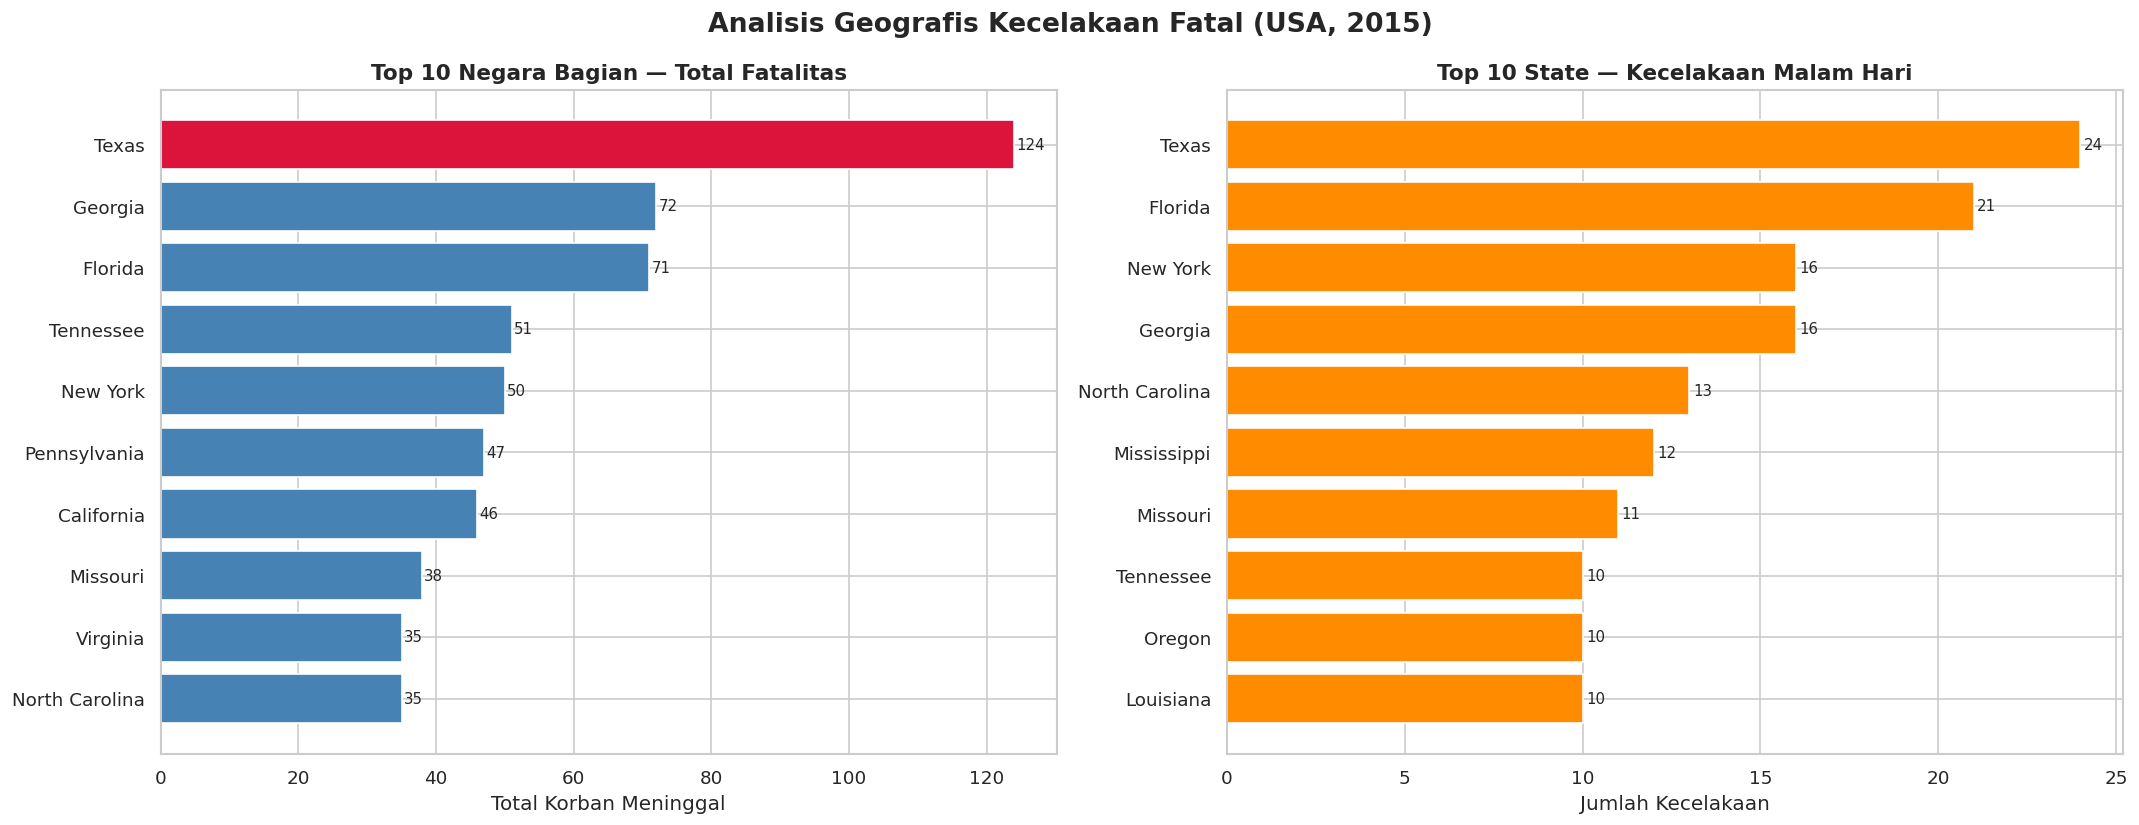

Chart 5-6 tersimpan!


In [9]:
fig2, axes2 = plt.subplots(1, 2, figsize=(18, 7))
fig2.suptitle('Analisis Geografis Kecelakaan Fatal (USA, 2015)',
              fontsize=16, fontweight='bold')

# Chart 5: Top 10 state total fatalitas
ax5 = axes2[0]
top10 = per_state.head(10).sort_values()
colors5 = ['crimson' if i == len(top10)-1 else 'steelblue'
           for i in range(len(top10))]
ax5.barh(top10.index, top10.values, color=colors5, edgecolor='white')
ax5.set_title('Top 10 Negara Bagian — Total Fatalitas', fontweight='bold', fontsize=13)
ax5.set_xlabel('Total Korban Meninggal')
for i, val in enumerate(top10.values):
    ax5.text(val + 0.3, i, str(int(val)), va='center', fontsize=9)

# Chart 6: Top 10 state kecelakaan malam
ax6 = axes2[1]
malam_df = df_clean[df_clean['waktu_kategori'] == 'Malam (18-23)']
top10_malam = malam_df.groupby('state_name').size().nlargest(10).sort_values()
ax6.barh(top10_malam.index, top10_malam.values,
         color='darkorange', edgecolor='white')
ax6.set_title('Top 10 State — Kecelakaan Malam Hari', fontweight='bold', fontsize=13)
ax6.set_xlabel('Jumlah Kecelakaan')
for i, val in enumerate(top10_malam.values):
    ax6.text(val + 0.1, i, str(int(val)), va='center', fontsize=9)

plt.tight_layout()
plt.savefig('chart_geografis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 5-6 tersimpan!")

In [10]:
print("RINGKASAN INSIGHT")
print(f"\n1. JAM PALING BERBAHAYA")
print(f"   Puncak kecelakaan terjadi pada jam {int(per_jam.idxmax())}:00")
print(f"   dengan {per_jam.max()} kejadian")
print(f"   Top 3 jam berbahaya:")
for jam, count in per_jam.nlargest(3).items():
    print(f"   → Jam {int(jam):02d}:00 : {count} kecelakaan")
print(f"\n2. HARI KERJA VS AKHIR PEKAN")
total = per_tipe.sum()
for tipe, count in per_tipe.items():
    print(f"   {tipe}: {count} kecelakaan ({count/total*100:.1f}%)")
print(f"\n3. BULAN PALING BERBAHAYA")
print(f"   Bulan paling fatal: {nama_bulan[int(per_bulan.idxmax())-1]}"
      f" ({per_bulan.max()} kecelakaan)")
print(f"   Top 3 bulan:")
for bln, count in per_bulan.nlargest(3).items():
    print(f"   → {nama_bulan[int(bln)-1]} : {count} kecelakaan")
print(f"\n4. TOP 10 NEGARA BAGIAN PALING FATAL (TOTAL)")
for i, (state, val) in enumerate(per_state.head(10).items(), 1):
    print(f"   {i:2}. {state:<20} : {int(val)} korban meninggal")
print(f"\n5. TOP 10 NEGARA DENGAN BANYAK KECELAKAAN DI MALAM HARI")
malam_df    = df_clean[df_clean['waktu_kategori'] == 'Malam (18-23)']
top10_malam = malam_df.groupby('state_name').size().nlargest(10)
for i, (state, val) in enumerate(top10_malam.items(), 1):
    print(f"   {i:2}. {state:<20} : {int(val)} kecelakaan malam")

RINGKASAN INSIGHT

1. JAM PALING BERBAHAYA
   Puncak kecelakaan terjadi pada jam 16:00
   dengan 75 kejadian
   Top 3 jam berbahaya:
   → Jam 16:00 : 75 kecelakaan
   → Jam 19:00 : 57 kecelakaan
   → Jam 21:00 : 55 kecelakaan

2. HARI KERJA VS AKHIR PEKAN
   Hari Kerja: 634 kecelakaan (64.2%)
   Akhir Pekan: 353 kecelakaan (35.8%)

3. BULAN PALING BERBAHAYA
   Bulan paling fatal: Nov (125 kecelakaan)
   Top 3 bulan:
   → Nov : 125 kecelakaan
   → Des : 105 kecelakaan
   → Jan : 102 kecelakaan

4. TOP 10 NEGARA BAGIAN PALING FATAL (TOTAL)
    1. Texas                : 124 korban meninggal
    2. Georgia              : 72 korban meninggal
    3. Florida              : 71 korban meninggal
    4. Tennessee            : 51 korban meninggal
    5. New York             : 50 korban meninggal
    6. Pennsylvania         : 47 korban meninggal
    7. California           : 46 korban meninggal
    8. Missouri             : 38 korban meninggal
    9. Virginia             : 35 korban meninggal
   10